# Использование Facial Landmarks в качестве Feature Estimator

**Студент**: Сидиков Константин

**Цель**: В этом ДЗ вы создадите свой пайплайн Facial Recognition.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - Выберите Facial Detector по вкусу.
 - Выполните Face Alignment.
 - На это натравите Facial Landmarks Detector по выбору.
 - На этом обучите классификатор на предпочитаемом датасете.

**План**:
1. **Датасет.** 5 случайных фотографий из `images/`.
2. **Аугментация.** Из 5 исходных снимков строим обучающую и тестовую выборки.
3. **Детектор landmarks.** **YOLO26-pose** (Ultralytics) — 17 точек COCO, из них
   голова = 5 точек: нос, два глаза, два уха.
4. **Face Alignment.** Similarity-преобразование по линии глаз приводит лицо к
   каноническому виду 224×224.
5. **Feature Estimator.** Из landmarks головы строим геометрический дескриптор,
   инвариантный к масштабу, повороту в плоскости и сдвигу.
6. **Классификатор.** LogReg / SVM-RBF / kNN / RandomForest поверх дескриптора.
7. **Сводка по пайплайну** и **выводы**.

In [1]:
from __future__ import annotations

import math
import os
import time
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ultralytics хочет писать настройки в конфиг-директорию — уводим её в проект,
# чтобы ноутбук не зависел от прав на /tmp и не засорял домашнюю директорию.
ROOT = Path.cwd()
os.environ.setdefault("YOLO_CONFIG_DIR", str(ROOT / ".cache" / "Ultralytics"))
(ROOT / ".cache" / "Ultralytics").mkdir(parents=True, exist_ok=True)

import torch
from ultralytics import YOLO

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

IMAGES_DIR = ROOT / "images"
MODELS_DIR = ROOT / "models";      MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR    = ROOT / "output";      OUT_DIR.mkdir(exist_ok=True)
AUG_DIR    = ROOT / "dataset_aug"

# Веса YOLO26-pose Ultralytics докачает сам при первом создании YOLO(...),
# но кладём их в models/, а не в рабочую директорию.
YOLO_POSE_WEIGHTS = MODELS_DIR / "yolo26n-pose.pt"

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

print(f"torch       {torch.__version__}   device={DEVICE}")
if torch.cuda.is_available():
    print(f"GPU         {torch.cuda.get_device_name(0)}")
print(f"ultralytics {__import__('ultralytics').__version__}")
print(f"opencv      {cv2.__version__}")
print(f"numpy       {np.__version__}")

torch       2.6.0+cu124   device=cuda:0
GPU         NVIDIA GeForce RTX 3090
ultralytics 8.4.135
opencv      5.0.0
numpy       2.4.6


## 1. Датасет

В папке `images/` лежат 5 фотографий случайных людей, по одной фотографии на человека. **Имя человека — это имя
файла без расширения** (`mr.actor.jpg` → `mr.actor`).

Длинную сторону снимков ужимаем до 720 px: это ускоряет инференс и не мешает
детектору — лица на портретах крупные.

In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def person_from_filename(path: Path) -> str:
    """Имя человека закодировано в имени файла: `mr.actor.jpg` -> `mr.actor`."""
    return Path(path).stem


def load_dataset(images_dir: Path, max_side: int = 720) -> list[dict]:
    items = []
    for p in sorted(Path(images_dir).iterdir()):
        if p.suffix.lower() not in IMG_EXT:
            continue
        bgr = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"не удалось прочитать {p}")
        h, w = bgr.shape[:2]
        s = max_side / max(h, w)
        if s < 1.0:
            bgr = cv2.resize(bgr, (round(w * s), round(h * s)), interpolation=cv2.INTER_AREA)
        items.append({"path": p, "person": person_from_filename(p), "image": bgr})
    return items


def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


items = load_dataset(IMAGES_DIR)
PERSONS = sorted({it["person"] for it in items})

pd.DataFrame([{"файл": it["path"].name,
               "человек": it["person"],
               "размер (после resize)": f'{it["image"].shape[1]}x{it["image"].shape[0]}'}
              for it in items])

,файл,человек,размер (после resize)
0,me.jpg,me,640x480
1,mr.actor.jpg,mr.actor,576x720
2,mr.black.jpeg,mr.black,480x720
3,mrs.actress.jpg,mrs.actress,576x720
4,mrs.cartoon.png,mrs.cartoon,480x720


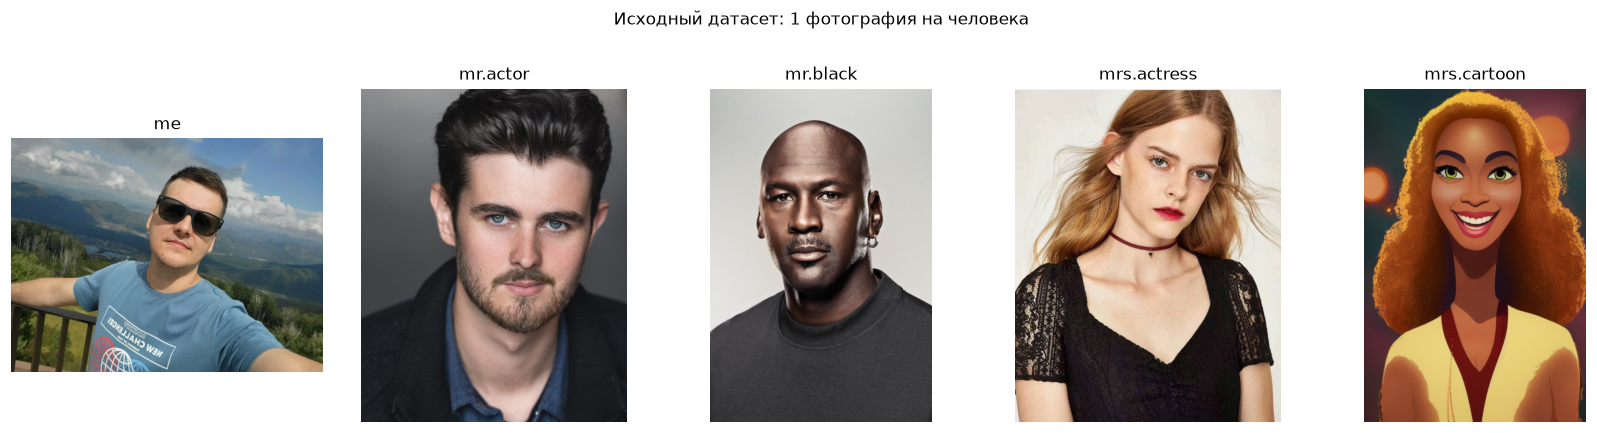

классов: 5 -> ['me', 'mr.actor', 'mr.black', 'mrs.actress', 'mrs.cartoon']
изображений: 5  (по одному на класс — задача one-shot)


In [3]:
fig, axes = plt.subplots(1, len(items), figsize=(3.0 * len(items), 3.8))
for ax, it in zip(np.atleast_1d(axes), items):
    ax.imshow(bgr2rgb(it["image"]));  ax.set_title(it["person"]);  ax.axis("off")
fig.suptitle("Исходный датасет: 1 фотография на человека", y=1.02)
plt.tight_layout();  plt.show()

print(f"классов: {len(PERSONS)} -> {PERSONS}")
print(f"изображений: {len(items)}  (по одному на класс — задача one-shot)")

## 2. Аугментация

| | train | test |
|---|---|---|
| поворот | ±12° | ±20° |
| масштаб | 0.90–1.10 | 0.80–1.20 |
| сдвиг | ±4 % | ±7 % |
| зеркало | да | да |
| яркость/контраст/цвет | **нет** | да |
| шум, размытие, JPEG | **нет** | да |

**Ключевая идея:** train содержит только *геометрические* преобразования, test —
геометрию в более широком диапазоне **плюс целый класс фотометрических искажений,
которых в обучении не было**.

In [4]:
def _warp(bgr, angle_deg, scale, tx, ty):
    """Поворот + масштаб + сдвиг вокруг центра кадра."""
    h, w = bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, scale)
    M[0, 2] += tx * w
    M[1, 2] += ty * h
    return cv2.warpAffine(bgr, M, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REPLICATE)


def _photometric(bgr, rng, strength=1.0):
    """Яркость, контраст, цветовой сдвиг, шум, расфокус, JPEG-артефакты."""
    out = bgr.astype(np.float32)
    out = out * (1.0 + rng.uniform(-0.30, 0.30) * strength) + rng.uniform(-35, 35) * strength
    out *= (1.0 + rng.uniform(-0.08, 0.08, size=3) * strength)
    out = np.clip(out, 0, 255)
    if rng.random() < 0.5:
        out = np.clip(out + rng.normal(0, 6.0 * strength, size=out.shape), 0, 255)
    out = out.astype(np.uint8)
    if rng.random() < 0.4:
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(out, (k, k), 0)
    if rng.random() < 0.3:
        q = int(rng.integers(35, 75))
        ok, enc = cv2.imencode(".jpg", out, [cv2.IMWRITE_JPEG_QUALITY, q])
        if ok:
            out = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return out


def augment(bgr, rng, policy: str):
    if policy == "train":
        out = _warp(bgr, rng.uniform(-12, 12), rng.uniform(0.90, 1.10),
                    rng.uniform(-0.04, 0.04), rng.uniform(-0.04, 0.04))
        return cv2.flip(out, 1) if rng.random() < 0.5 else out
    if policy == "test":
        out = _warp(bgr, rng.uniform(-20, 20), rng.uniform(0.80, 1.20),
                    rng.uniform(-0.07, 0.07), rng.uniform(-0.07, 0.07))
        if rng.random() < 0.5:
            out = cv2.flip(out, 1)
        return _photometric(out, rng, strength=1.0)
    raise ValueError(policy)


def build_augmented_dataset(items, n_train=40, n_test=20, seed=SEED, out_dir=None):
    """
    Возвращает записи {person, split, aug_id, image, src}.
    Оригинал попадает в train под aug_id=0 — это единственный «настоящий» кадр.
    Фиксированные seed'ы на каждый вариант делают выборку воспроизводимой.
    """
    rng_master = np.random.default_rng(seed)
    records = []
    for it in items:
        person, base = it["person"], it["image"]
        records.append({"person": person, "split": "train", "aug_id": 0,
                        "image": base.copy(), "src": it["path"].name})
        seeds = rng_master.integers(0, 2**31 - 1, size=n_train + n_test)
        for i in range(n_train):
            rng = np.random.default_rng(int(seeds[i]))
            records.append({"person": person, "split": "train", "aug_id": i + 1,
                            "image": augment(base, rng, "train"), "src": it["path"].name})
        for j in range(n_test):
            rng = np.random.default_rng(int(seeds[n_train + j]))
            records.append({"person": person, "split": "test", "aug_id": 1000 + j,
                            "image": augment(base, rng, "test"), "src": it["path"].name})
    if out_dir is not None:
        out_dir = Path(out_dir)
        for r in records:
            d = out_dir / r["split"] / r["person"]
            d.mkdir(parents=True, exist_ok=True)
            fp = d / f"{r['person']}_{r['aug_id']:04d}.jpg"
            cv2.imwrite(str(fp), r["image"], [cv2.IMWRITE_JPEG_QUALITY, 95])
            r["path"] = fp
    return records


records = build_augmented_dataset(items, n_train=40, n_test=20, seed=SEED, out_dir=AUG_DIR)

df_ds = pd.DataFrame([{k: r[k] for k in ("person", "split", "aug_id", "src")} for r in records])
print(f"всего кадров: {len(records)};  сохранены в {AUG_DIR.relative_to(ROOT)}/")
df_ds.pivot_table(index="person", columns="split", values="aug_id", aggfunc="count")

всего кадров: 305;  сохранены в dataset_aug/


split,test,train
person,,
me,20,41
mr.actor,20,41
mr.black,20,41
mrs.actress,20,41
mrs.cartoon,20,41


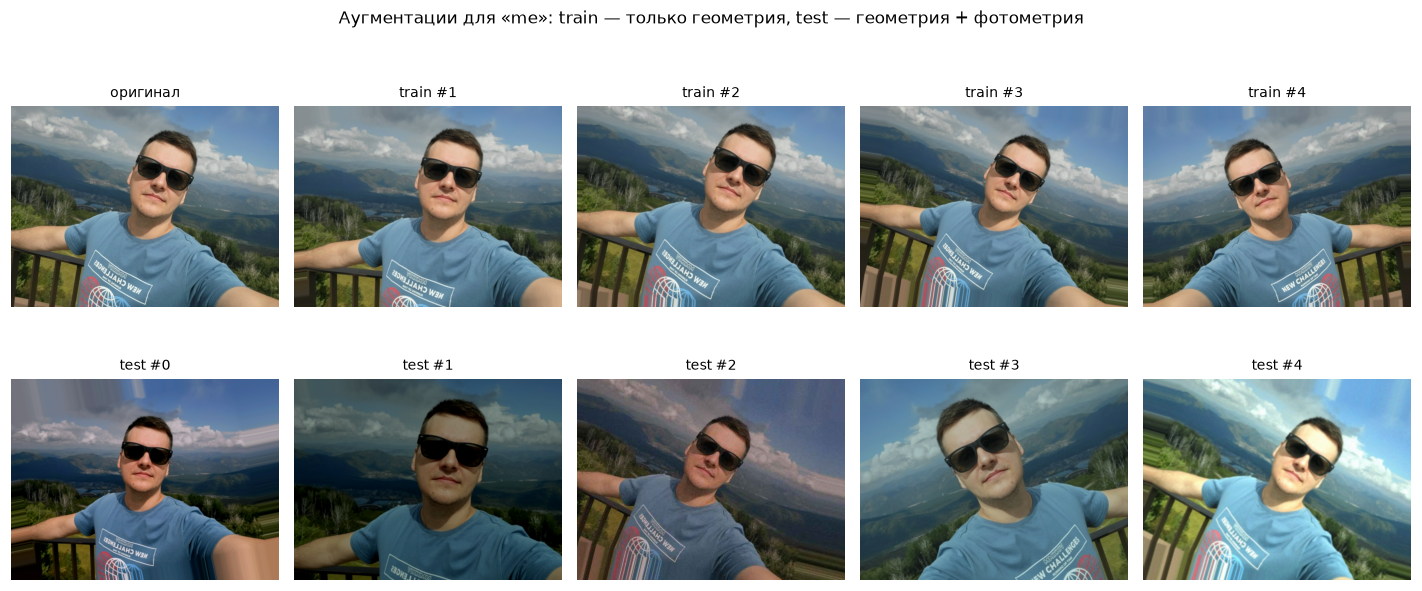

In [5]:
# Как выглядят аугментации: слева оригинал, затем train-варианты, затем test-варианты
demo_person = PERSONS[0]
tr = [r for r in records if r["person"] == demo_person and r["split"] == "train"][:5]
te = [r for r in records if r["person"] == demo_person and r["split"] == "test"][:5]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, r in zip(axes[0], tr):
    ax.imshow(bgr2rgb(r["image"]))
    ax.set_title("оригинал" if r["aug_id"] == 0 else f"train #{r['aug_id']}", fontsize=9)
    ax.axis("off")
for ax, r in zip(axes[1], te):
    ax.imshow(bgr2rgb(r["image"]));  ax.set_title(f"test #{r['aug_id']-1000}", fontsize=9);  ax.axis("off")
fig.suptitle(f"Аугментации для «{demo_person}»: train — только геометрия, test — геометрия + фотометрия")
plt.tight_layout();  plt.show()

## 3. Детектор landmarks: YOLO26-pose

Ключевые точки берём у **YOLO26-pose** (Ultralytics). Модель решает задачу
pose estimation и выдаёт 17 точек скелета в формате COCO; нам из них нужны
только точки головы.

| | YOLO26-pose |
|---|---|
| всего точек | 17 (COCO) |
| точек на голове | **5**: нос, 2 глаза, 2 уха |
| координаты | пиксели + confidence на каждую точку |
| инференс | GPU (PyTorch/CUDA), веса `yolo26n-pose.pt` |
| многолюдность | детектит всех людей в кадре, берём самого крупного |

Детекцию лица и landmarks выполняет YOLO26-pose (берём самый крупный баундинг бокс на фото).

Результат кладем в датакласс `Landmarks` — дальше пайплайн работает с ним,
а не с внутренним форматом Ultralytics.

In [6]:
# --- COCO-17: порядок ключевых точек у всех pose-моделей YOLO --------------
COCO_KPT = ["nose", "left_eye", "right_eye", "left_ear", "right_ear",
            "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
            "left_wrist", "right_wrist", "left_hip", "right_hip",
            "left_knee", "right_knee", "left_ankle", "right_ankle"]
COCO_SKELETON = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9),
                 (6, 8), (8, 10), (5, 11), (6, 12), (11, 12),
                 (11, 13), (13, 15), (12, 14), (14, 16)]
COCO_HEAD = [0, 1, 2, 3, 4]          # нос, левый/правый глаз, левое/правое ухо
NOSE_IDX = COCO_KPT.index("nose")


@dataclass
class Landmarks:
    """Результат детектора в едином виде, независимом от Ultralytics."""
    ok: bool
    xy: np.ndarray | None = None          # (K, 2), пиксели исходного кадра
    conf: np.ndarray | None = None        # (K,), confidence по каждой точке
    head_idx: list[int] = field(default_factory=list)
    skeleton: list[tuple] = field(default_factory=list)
    # индексы глаз в ЭКРАННОМ порядке: (виден слева, виден справа)
    eyes_img: tuple[int, int] = (0, 0)
    elapsed: float = 0.0

In [7]:
class YoloPoseEstimator:
    """Обёртка над Ultralytics YOLO26-pose (17 keypoints COCO)."""

    def __init__(self, weights=YOLO_POSE_WEIGHTS, device=DEVICE, conf=0.25, imgsz=640):
        self.model = YOLO(str(weights))
        self.device, self.conf, self.imgsz = device, conf, imgsz
        self.name = f"YOLO26-pose ({Path(weights).name}, {device})"

    def __call__(self, bgr) -> Landmarks:
        t0 = time.perf_counter()
        res = self.model.predict(bgr, device=self.device, conf=self.conf,
                                 imgsz=self.imgsz, verbose=False)[0]
        dt = time.perf_counter() - t0
        if res.keypoints is None or len(res.boxes) == 0:
            return Landmarks(ok=False, elapsed=dt)
        # если в кадре несколько людей — берём самого крупного (герой портрета)
        areas = (res.boxes.xywh[:, 2] * res.boxes.xywh[:, 3]).cpu().numpy()
        data = res.keypoints.data[int(np.argmax(areas))].cpu().numpy()   # (17, 3)
        return Landmarks(ok=True,
                         xy=data[:, :2].astype(np.float64),
                         conf=data[:, 2].astype(np.float64),
                         head_idx=COCO_HEAD, skeleton=COCO_SKELETON,
                         eyes_img=(2, 1), elapsed=dt)


EST = YoloPoseEstimator()
HEAD_N = len(COCO_HEAD)
print(EST.name)

YOLO26-pose (yolo26n-pose.pt, cuda:0)


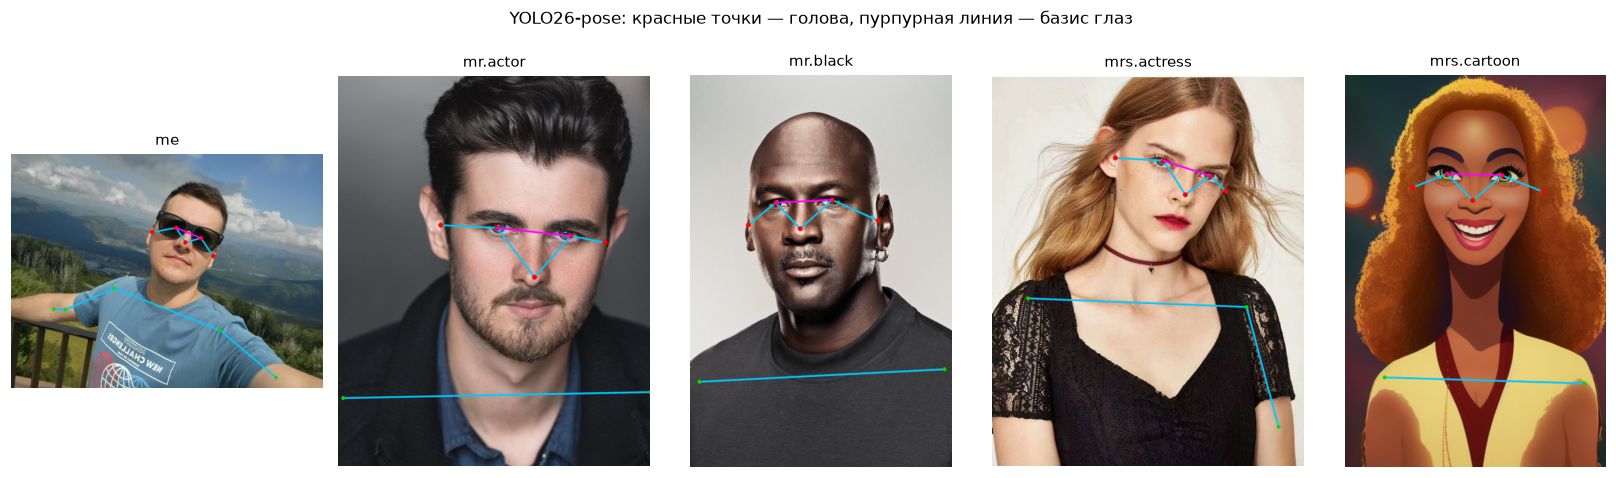

In [8]:
def draw_landmarks(bgr, lm: Landmarks, head_only=False, radius=3, thickness=2):
    """Рисует скелет и ключевые точки; точки головы выделены цветом."""
    vis = bgr.copy()
    if not lm.ok:
        cv2.putText(vis, "NO DETECTION", (12, 34), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (0, 0, 255), 2)
        return vis
    head = set(lm.head_idx)
    if not head_only:
        for a, b in lm.skeleton:
            if lm.conf[a] > 0.3 and lm.conf[b] > 0.3:
                cv2.line(vis, tuple(lm.xy[a].astype(int)), tuple(lm.xy[b].astype(int)),
                         (255, 200, 0), thickness, cv2.LINE_AA)
    for i, (x, y) in enumerate(lm.xy):
        if head_only and i not in head:
            continue
        if lm.conf[i] < 0.3:
            continue
        color = (0, 0, 255) if i in head else (0, 220, 0)
        cv2.circle(vis, (int(x), int(y)), radius + (1 if i in head else 0), color, -1, cv2.LINE_AA)
    # линия глаз — базис для alignment
    li, ri = lm.eyes_img
    cv2.line(vis, tuple(lm.xy[li].astype(int)), tuple(lm.xy[ri].astype(int)),
             (255, 0, 255), 2, cv2.LINE_AA)
    return vis


fig, axes = plt.subplots(1, len(items), figsize=(3.0 * len(items), 4.2))
for ax, it in zip(np.atleast_1d(axes), items):
    ax.imshow(bgr2rgb(draw_landmarks(it["image"], EST(it["image"]))))
    ax.set_title(it["person"], fontsize=10);  ax.axis("off")
fig.suptitle("YOLO26-pose: красные точки — голова, пурпурная линия — базис глаз", y=1.02)
plt.tight_layout();  plt.show()

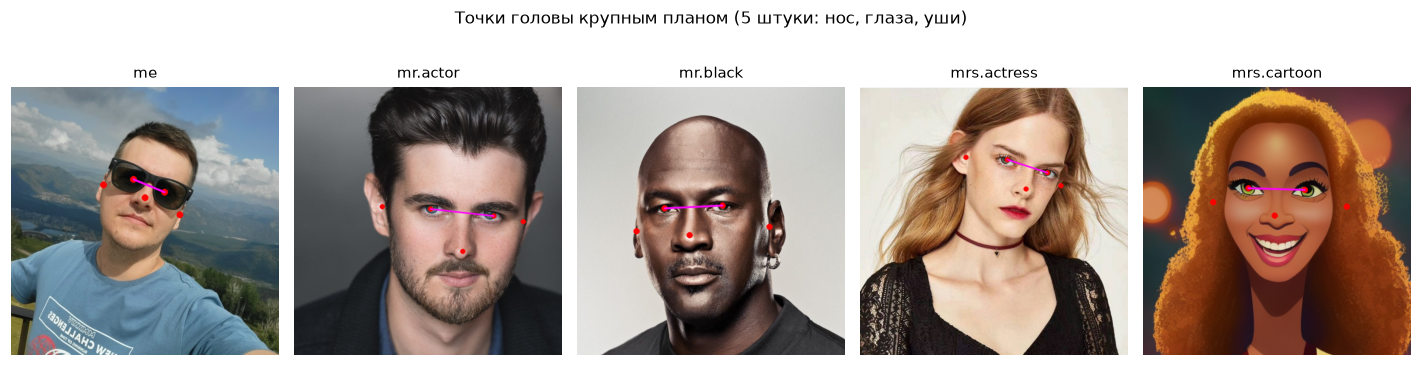

In [9]:
# Крупный план головы: всего пять точек, и на них держится весь дальнейший пайплайн
fig, axes = plt.subplots(1, len(items), figsize=(2.6 * len(items), 3.4))
for ax, it in zip(np.atleast_1d(axes), items):
    lm = EST(it["image"])
    vis = draw_landmarks(it["image"], lm, head_only=True, radius=4)
    if lm.ok:
        pts = lm.xy[lm.head_idx]
        h, w = vis.shape[:2]
        # квадратное окно вокруг точек головы; центр сдвигаем внутрь кадра,
        # чтобы окно не обрезалось краем и все панели были одного размера
        half = 1.6 * np.linalg.norm(pts.max(axis=0) - pts.min(axis=0))
        half = float(np.clip(half, 50.0, min(h, w) / 2))
        cx = float(np.clip(pts.mean(axis=0)[0], half, w - half))
        cy = float(np.clip(pts.mean(axis=0)[1], half, h - half))
        vis = vis[int(cy - half):int(cy + half), int(cx - half):int(cx + half)]
    ax.imshow(bgr2rgb(vis));  ax.set_title(it["person"], fontsize=10);  ax.axis("off")
fig.suptitle(f"Точки головы крупным планом ({HEAD_N} штуки: нос, глаза, уши)", y=1.02)
plt.tight_layout();  plt.show()

## 4. Face Alignment

Приводим все лица к одному виду.

**Двигаем картинку, пока глаза не встанут в фиксированные точки** кадра 224×224 —
(81, 90) и (143, 90). Разрешён поворот, равномерный масштаб и сдвиг.
В результате получаем горизонтальную линия глаз, между зрачками ровно
63 пикселя, лицо всегда в одном месте кадра.


In [10]:
ALIGN_SIZE = 224
EYE_L_CANON = np.array([0.36, 0.40])   # доли кадра, глаз в ЛЕВОЙ части картинки
EYE_R_CANON = np.array([0.64, 0.40])


def align_face(bgr, lm: Landmarks, size: int = ALIGN_SIZE, min_conf: float = 0.05):
    """
    Возвращает (aligned_bgr, xy_aligned) или (None, None), если выровнять нельзя.
    xy_aligned — все landmarks, пересчитанные в координаты выровненного кадра.
    """
    if not lm.ok:
        return None, None
    li, ri = lm.eyes_img
    p_left, p_right = lm.xy[li], lm.xy[ri]
    if not np.all(np.isfinite(np.stack([p_left, p_right]))) or np.allclose(p_left, p_right):
        return None, None
    if lm.conf is not None and min(lm.conf[li], lm.conf[ri]) < min_conf:
        return None, None

    src = np.stack([p_left, p_right]).astype(np.float64)
    dst = np.stack([EYE_L_CANON, EYE_R_CANON]).astype(np.float64) * size

    d_src, d_dst = src[1] - src[0], dst[1] - dst[0]
    scale = np.linalg.norm(d_dst) / (np.linalg.norm(d_src) + 1e-9)
    ang = math.atan2(d_dst[1], d_dst[0]) - math.atan2(d_src[1], d_src[0])
    cos_a, sin_a = math.cos(ang) * scale, math.sin(ang) * scale
    M = np.array([[cos_a, -sin_a, 0.0],
                  [sin_a,  cos_a, 0.0]])
    M[:, 2] = dst[0] - M[:, :2] @ src[0]

    aligned = cv2.warpAffine(bgr, M, (size, size), flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    xy_h = np.hstack([lm.xy, np.ones((len(lm.xy), 1))])
    return aligned, (M @ xy_h.T).T

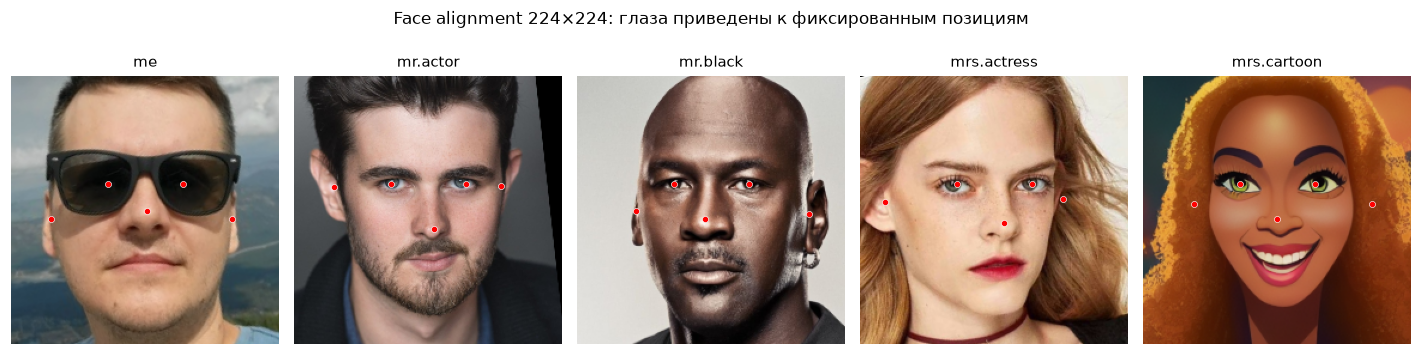

In [11]:
fig, axes = plt.subplots(1, len(items), figsize=(2.6 * len(items), 3.2))
for ax, it in zip(np.atleast_1d(axes), items):
    lm = EST(it["image"])
    aligned, xya = align_face(it["image"], lm)
    ax.axis("off");  ax.set_title(it["person"], fontsize=10)
    if aligned is None:
        ax.imshow(np.zeros((ALIGN_SIZE, ALIGN_SIZE, 3), np.uint8))
        ax.set_title("alignment failed", fontsize=8, color="red")
        continue
    ax.imshow(bgr2rgb(aligned))
    pts = xya[lm.head_idx]
    ax.scatter(pts[:, 0], pts[:, 1], s=16, c="red", edgecolors="white", linewidths=0.4)
fig.suptitle("Face alignment 224×224: глаза приведены к фиксированным позициям", y=1.02)
plt.tight_layout();  plt.show()

## 5. Feature Estimator: дескриптор из landmarks

Из пяти точек головы в **выровненной** системе координат формируем вектор
признаков. Всё нормируется на межзрачковое расстояние (IOD) и отсчитывается от
середины линии глаз, поэтому дескриптор инвариантен к масштабу, сдвигу и
повороту в плоскости:

| блок | что это | размер (K = 5 точек) |
|---|---|---|
| `coords` | координаты точек относительно центра глаз / IOD | 2K = 10 |
| `dists` | все попарные расстояния / IOD | K(K−1)/2 = 10 |
| `angles` | cos и sin угла «центр глаз → точка» | 2K = 10 |

Итого **30 признаков**.

Дополнительно считаем **HOG** (Histogram of Oriented Gradients) по выровненному кадру.
Используем **HOG** в качестве baseline, для сравнения с landmarks.

In [12]:
from skimage.feature import hog


def landmark_features(lm: Landmarks, xy_aligned: np.ndarray) -> np.ndarray | None:
    """Геометрический дескриптор лица из landmarks головы."""
    if xy_aligned is None or not lm.ok:
        return None
    idx = lm.head_idx
    pts = xy_aligned[idx]
    if not np.all(np.isfinite(pts)):
        return None

    li, ri = lm.eyes_img
    eye_l, eye_r = xy_aligned[li], xy_aligned[ri]
    iod = np.linalg.norm(eye_r - eye_l)
    if iod < 1e-6:
        return None
    center = (eye_l + eye_r) / 2.0

    coords = ((pts - center) / iod).ravel()                     # 2K
    d = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1) / iod
    dists = d[np.triu_indices(len(idx), k=1)]                   # K(K-1)/2
    v = pts - center
    ang = np.arctan2(v[:, 1], v[:, 0])
    angs = np.concatenate([np.cos(ang), np.sin(ang)])           # 2K
    # confidence сознательно НЕ включаем: это свойство кадра, а не лица
    return np.concatenate([coords, dists, angs]).astype(np.float32)


def hog_features(aligned_bgr) -> np.ndarray | None:
    """HOG по выровненному кадру — контрольный признак «текстура лица»."""
    if aligned_bgr is None:
        return None
    gray = cv2.resize(cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2GRAY), (128, 128),
                      interpolation=cv2.INTER_AREA)
    return hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
               block_norm="L2-Hys", feature_vector=True).astype(np.float32)


# размерности дескрипторов
_lm = EST(items[0]["image"])
_al, _xya = align_face(items[0]["image"], _lm)
print(f"точек головы: {HEAD_N}   landmark-дескриптор: {landmark_features(_lm, _xya).shape[0]}   "
      f"HOG: {hog_features(_al).shape[0]}")

точек головы: 5   landmark-дескриптор: 30   HOG: 1764


### Прогон детектора по всей выборке

In [13]:
def extract_all(records, est):
    """Детекция -> alignment -> признаки для каждого кадра выборки."""
    rows = []
    t_start = time.perf_counter()
    for r in records:
        lm = est(r["image"])
        aligned, xya = align_face(r["image"], lm)
        rows.append({
            "person": r["person"], "split": r["split"], "aug_id": r["aug_id"],
            "detected": bool(lm.ok),
            "aligned": aligned is not None,
            "t_ms": lm.elapsed * 1000.0,
            "f_lm": landmark_features(lm, xya),
            "f_hog": hog_features(aligned),
            "aligned_img": aligned,
            "xy_aligned": xya,
            "conf_head": float(np.mean(lm.conf[lm.head_idx])) if lm.ok else np.nan,
        })
    print(f"готово за {time.perf_counter()-t_start:.1f} с ({len(records)} кадров)")
    return rows


feats = extract_all(records, EST)

готово за 2.7 с (305 кадров)


In [14]:
# Сводка по качеству детекции и скорости
det = np.array([r["detected"] for r in feats])
ali = np.array([r["aligned"] for r in feats])
t   = np.array([r["t_ms"] for r in feats])

df_det = pd.DataFrame([{
    "детектор": "YOLO26-pose",
    "точек головы": HEAD_N,
    "detection rate, %": round(100 * det.mean(), 1),
    "alignment rate, %": round(100 * ali.mean(), 1),
    "медиана t, мс": round(float(np.median(t)), 1),
    "средняя conf головы": round(float(np.nanmean([r["conf_head"] for r in feats])), 3),
}])
df_det

,детектор,точек головы,"detection rate, %","alignment rate, %","медиана t, мс",средняя conf головы
0,YOLO26-pose,5,99.7,99.7,6.8,0.941


In [15]:
# Проверка утверждений о дескрипторе: сколько колонок константны и сколько
# среди оставшихся действительно независимых направлений
X_all = np.vstack([r["f_lm"] for r in feats if r["f_lm"] is not None])
n_const = int((X_all.std(axis=0) < 1e-9).sum())
print(f"dim={X_all.shape[1]}   константных признаков: {n_const}   "
      f"информативных: {X_all.shape[1] - n_const}")

Xv = X_all[:, X_all.std(axis=0) >= 1e-9]
Xv = (Xv - Xv.mean(0)) / Xv.std(0)
sv = np.linalg.svd(Xv, compute_uv=False)
cum = np.cumsum(sv**2) / (sv**2).sum()
print(f"эффективный ранг: {int(np.searchsorted(cum, 0.99) + 1)} компонент объясняют 99 % дисперсии "
      f"({int(np.searchsorted(cum, 0.95) + 1)} — 95 %)")
print("теоретический предел: после alignment свободны только нос и два уха -> 3 точки x 2 координаты = 6")

dim=30   константных признаков: 9   информативных: 21
эффективный ранг: 5 компонент объясняют 99 % дисперсии (4 — 95 %)
теоретический предел: после alignment свободны только нос и два уха -> 3 точки x 2 координаты = 6


In [16]:
# Где именно детектор сорвался — важно для интерпретации метрик
bad = [r for r in feats if not r["aligned"]]
if not bad:
    print("сбоев alignment нет")
else:
    print(f"сбоев: {len(bad)} из {len(feats)}")
    print(pd.Series([r["person"] for r in bad]).value_counts().to_string())

сбоев: 1 из 305
me    1


### Проверяем жизнеспособность дескриптора

До обучения классификатора полезно померить сам признак. Две метрики:

* **Fisher ratio** — `trace(S_b) / trace(S_w)`, отношение межклассового разброса
  к внутриклассовому. Чем больше, тем легче задача любому классификатору. Полезно
  сравнить значение на train и на test: заметное падение означает, что
  фотометрические искажения «размывают» классы.
* **Стабильность alignment** — разброс положения кончика носа в выровненном
  кадре внутри одного человека (px). Показывает, насколько повторяемо детектор
  ставит опорные точки при искажениях кадра.

In [17]:
def stack_features(rows, split, key="f_lm"):
    """Собирает матрицу признаков X и метки y, пропуская кадры без детекции."""
    X, y = [], []
    for r in rows:
        if r["split"] != split or r[key] is None:
            continue
        X.append(r[key]);  y.append(r["person"])
    return (np.vstack(X) if X else np.empty((0, 0))), np.array(y)


def fisher_ratio(X, y):
    """trace(S_b)/trace(S_w) на стандартизованных признаках."""
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-8)
    mu = Xs.mean(0)
    sw = sb = 0.0
    for c in np.unique(y):
        Xc = Xs[y == c]
        mc = Xc.mean(0)
        sw += ((Xc - mc) ** 2).sum()
        sb += len(Xc) * ((mc - mu) ** 2).sum()
    return float(sb / (sw + 1e-12))


Xtr, ytr = stack_features(feats, "train")
Xte, yte = stack_features(feats, "test")

nose_std = []
for person in PERSONS:
    pts = [r["xy_aligned"][NOSE_IDX] for r in feats
           if r["person"] == person and r["xy_aligned"] is not None]
    if len(pts) > 1:
        nose_std.append(np.std(np.vstack(pts), axis=0).mean())

df_quality = pd.DataFrame([{
    "размерность": Xtr.shape[1],
    "Fisher ratio (train)": round(fisher_ratio(Xtr, ytr), 2),
    "Fisher ratio (test)": round(fisher_ratio(Xte, yte), 2),
    "разброс носа после alignment, px": round(float(np.mean(nose_std)), 2),
}])
df_quality

,размерность,Fisher ratio (train),Fisher ratio (test),"разброс носа после alignment, px"
0,30,0.88,0.75,2.85


## 6. Классификатор

Обучаем четыре классических модели поверх дескриптора и сравниваем три набора
признаков:

* `landmarks` — только геометрия ключевых точек (то, ради чего задание);
* `hog` — HOG по выровненному кадру (контроль: текстура вместо геометрии);
* `landmarks+hog` — конкатенация.

Оценка двойная: 5-fold стратифицированная кросс-валидация **на train** и
финальный прогон на **отложенном test** с невиданными типами искажений.

Важно: «лучшая модель» дальше выбирается **по кросс-валидации на train**, а не по
test. Выбор по test — это подглядывание в отложенную выборку, оно завышает
итоговую цифру. Test участвует только в финальном замере.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def make_models():
    return {
        "LogReg": Pipeline([("sc", StandardScaler()),
                            ("clf", LogisticRegression(max_iter=5000, C=1.0))]),
        "SVM-RBF": Pipeline([("sc", StandardScaler()),
                             ("clf", SVC(kernel="rbf", C=10.0, gamma="scale",
                                         random_state=SEED))]),
        "kNN-3": Pipeline([("sc", StandardScaler()),
                           ("clf", KNeighborsClassifier(n_neighbors=3, weights="distance"))]),
        "RandomForest": Pipeline([("sc", StandardScaler()),
                                  ("clf", RandomForestClassifier(n_estimators=400,
                                                                 random_state=SEED))]),
    }


FEATURE_SETS = {
    "landmarks": ("f_lm",),
    "hog": ("f_hog",),
    "landmarks+hog": ("f_lm", "f_hog"),
}


def build_xy(rows, split, fields):
    X, y = [], []
    for r in rows:
        if r["split"] != split:
            continue
        parts = [r[f] for f in fields]
        if any(p is None for p in parts):
            continue
        X.append(np.concatenate(parts));  y.append(r["person"])
    return np.vstack(X), np.array(y)


results, fitted = [], {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fs_name, fields in FEATURE_SETS.items():
    Xtr_, ytr_ = build_xy(feats, "train", fields)
    Xte_, yte_ = build_xy(feats, "test", fields)
    for m_name, model in make_models().items():
        cv_acc = cross_val_score(model, Xtr_, ytr_, cv=cv, scoring="accuracy", n_jobs=-1)
        model.fit(Xtr_, ytr_)
        pred = model.predict(Xte_)
        results.append({
            "признаки": fs_name, "модель": m_name, "dim": Xtr_.shape[1],
            "CV acc (train)": round(float(cv_acc.mean()), 3),
            "CV std": round(float(cv_acc.std()), 3),
            "test acc": round(accuracy_score(yte_, pred), 3),
            "test macro-F1": round(f1_score(yte_, pred, average="macro"), 3),
        })
        fitted[(fs_name, m_name)] = (model, Xte_, yte_, pred)

df_res = pd.DataFrame(results).sort_values(["признаки", "CV acc (train)"],
                                           ascending=[True, False])
df_res.reset_index(drop=True)

,признаки,модель,dim,CV acc (train),CV std,test acc,test macro-F1
0,hog,LogReg,1764,1.000,0.000,1.00,1.00
1,hog,SVM-RBF,1764,1.000,0.000,1.00,1.00
2,hog,kNN-3,1764,1.000,0.000,1.00,1.00
3,hog,RandomForest,1764,1.000,0.000,1.00,1.00
4,landmarks,LogReg,30,1.000,0.000,0.96,0.96
5,landmarks,RandomForest,30,1.000,0.000,0.98,0.98
6,landmarks,SVM-RBF,30,0.980,0.024,0.95,0.95
7,landmarks,kNN-3,30,0.961,0.033,0.93,0.93
8,landmarks+hog,LogReg,1794,1.000,0.000,1.00,1.00
9,landmarks+hog,SVM-RBF,1794,1.000,0.000,1.00,1.00


In [19]:
# Лучшая модель для каждого набора признаков.
# Критерий — CV-accuracy на train; ничьи разводятся меньшим разбросом CV,
# затем именем модели, чтобы выбор был детерминированным и не зависел от test.
best = (df_res.sort_values(["CV acc (train)", "CV std", "модель"],
                           ascending=[False, True, True])
              .groupby("признаки", as_index=False).first())
best.reset_index(drop=True)

,признаки,модель,dim,CV acc (train),CV std,test acc,test macro-F1
0,hog,LogReg,1764,1.0,0.0,1.00,1.00
1,landmarks,LogReg,30,1.0,0.0,0.96,0.96
2,landmarks+hog,LogReg,1794,1.0,0.0,1.00,1.00


In [20]:
# Сводная таблица: строки — набор признаков, столбцы — модели
df_res.pivot_table(index="признаки", columns="модель", values="test acc")

модель,LogReg,RandomForest,SVM-RBF,kNN-3
признаки,,,,
hog,1.00,1.00,1.00,1.00
landmarks,0.96,0.98,0.95,0.93
landmarks+hog,1.00,1.00,1.00,1.00


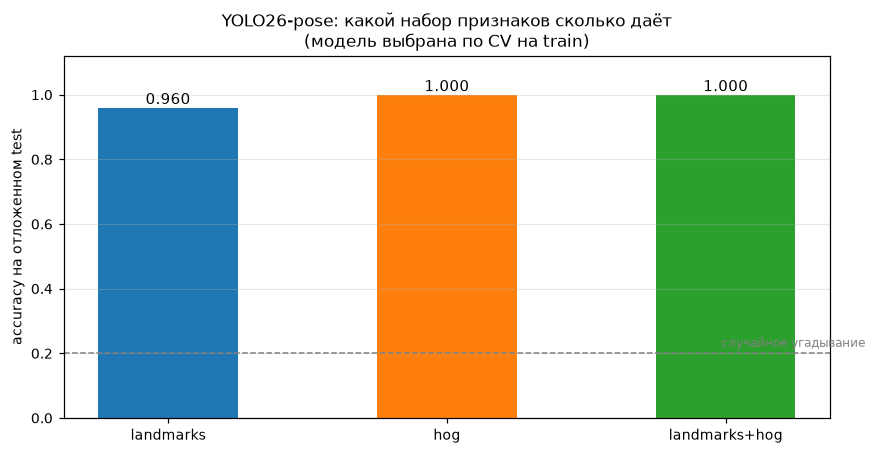

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.2))
labels = list(FEATURE_SETS)
vals = [best[best["признаки"] == fs]["test acc"].iloc[0] for fs in labels]
bars = ax.bar(labels, vals, width=0.5, color=["tab:blue", "tab:orange", "tab:green"])
ax.bar_label(bars, fmt="%.3f", fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("accuracy на отложенном test")
ax.set_title("YOLO26-pose: какой набор признаков сколько даёт\n(модель выбрана по CV на train)")
ax.axhline(1 / len(PERSONS), ls="--", c="gray", lw=1)
ax.text(len(labels) - 0.5, 1 / len(PERSONS) + 0.02, "случайное угадывание",
        ha="right", fontsize=8, color="gray")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout();  plt.show()

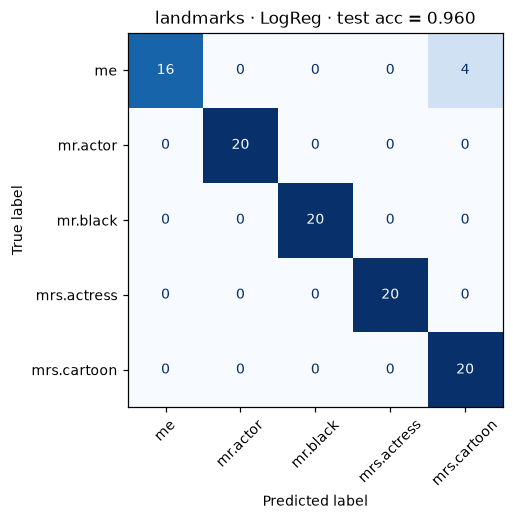

              precision    recall  f1-score   support

          me       1.00      0.80      0.89        20
    mr.actor       1.00      1.00      1.00        20
    mr.black       1.00      1.00      1.00        20
 mrs.actress       1.00      1.00      1.00        20
 mrs.cartoon       0.83      1.00      0.91        20

    accuracy                           0.96       100
   macro avg       0.97      0.96      0.96       100
weighted avg       0.97      0.96      0.96       100



In [22]:
# Матрица ошибок для набора «landmarks» — именно он проверяет гипотезу задания
row = best[best["признаки"] == "landmarks"].iloc[0]
_, _, yte_lm, pred_lm = fitted[("landmarks", row["модель"])]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
ConfusionMatrixDisplay(confusion_matrix(yte_lm, pred_lm, labels=PERSONS),
                       display_labels=PERSONS).plot(ax=ax, cmap="Blues",
                                                    colorbar=False, xticks_rotation=45)
ax.set_title(f"landmarks · {row['модель']} · test acc = {row['test acc']:.3f}")
plt.tight_layout();  plt.show()

print(classification_report(yte_lm, pred_lm, labels=PERSONS, zero_division=0))

## 7. Сводка по пайплайну

Собираем в одну таблицу всё, что измерено: качество детекции, скорость, свойства
дескриптора и итоговую точность.

In [23]:
b_lm = best[best["признаки"] == "landmarks"].iloc[0]
b_all = best.sort_values(["CV acc (train)", "CV std"], ascending=[False, True]).iloc[0]

df_summary = pd.DataFrame([{
    "детектор": "YOLO26-pose (yolo26n-pose.pt)",
    "точек на голове": HEAD_N,
    "dim дескриптора": int(b_lm["dim"]),
    "detection rate, %": df_det["detection rate, %"].iloc[0],
    "медиана t, мс": df_det["медиана t, мс"].iloc[0],
    "Fisher ratio (train / test)":
        f'{df_quality["Fisher ratio (train)"].iloc[0]} / {df_quality["Fisher ratio (test)"].iloc[0]}',
    "разброс носа, px": df_quality["разброс носа после alignment, px"].iloc[0],
    "landmarks: test acc": b_lm["test acc"],
    "landmarks: модель": b_lm["модель"],
    "лучший набор признаков": f'{b_all["признаки"]}, {b_all["модель"]} -> test {b_all["test acc"]:.3f}',
}]).T.rename(columns={0: "значение"})
df_summary

,значение
детектор,YOLO26-pose (yolo26n-pose.pt)
точек на голове,5
dim дескриптора,30
"detection rate, %",99.7
"медиана t, мс",6.8
Fisher ratio (train / test),0.88 / 0.75
"разброс носа, px",2.85
landmarks: test acc,0.96
landmarks: модель,LogReg
лучший набор признаков,"hog, LogReg -> test 1.000"


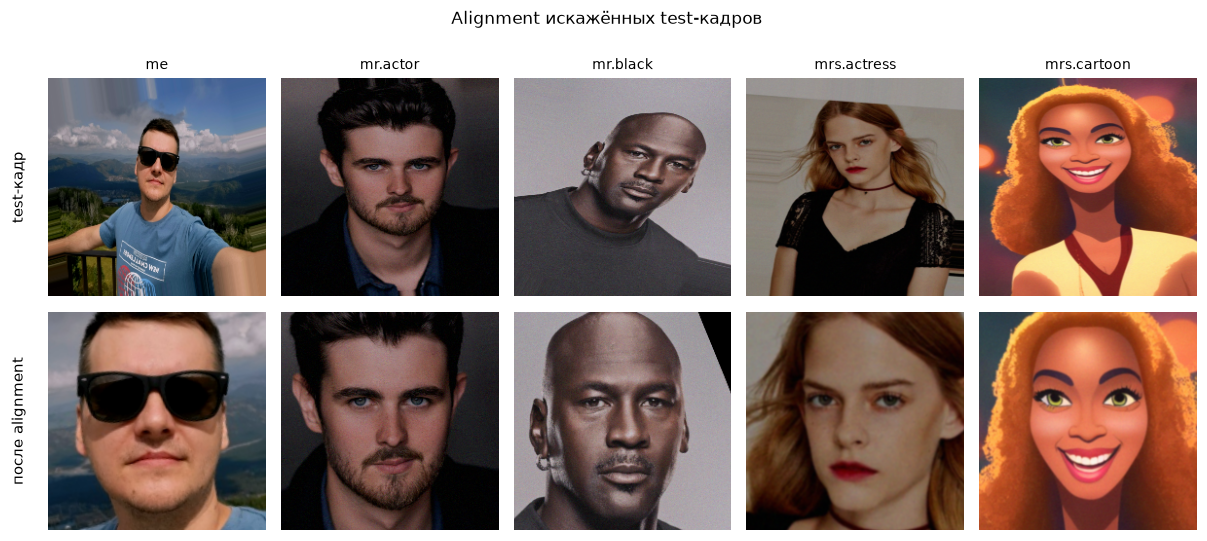

In [24]:
# Как выглядит alignment на искажённых test-кадрах: сверху вход, снизу результат
sample = [next(r for r in records if r["split"] == "test" and r["person"] == p)
          for p in PERSONS]
fig, axes = plt.subplots(2, len(sample), figsize=(2.2 * len(sample), 5.0))
for col, r in enumerate(sample):
    axes[0, col].imshow(bgr2rgb(cv2.resize(r["image"], (ALIGN_SIZE, ALIGN_SIZE))))
    axes[0, col].set_title(r["person"], fontsize=9)
    rec = next(x for x in feats
               if x["person"] == r["person"] and x["aug_id"] == r["aug_id"])
    img = rec["aligned_img"]
    axes[1, col].imshow(bgr2rgb(img) if img is not None
                        else np.zeros((ALIGN_SIZE, ALIGN_SIZE, 3), np.uint8))
for row, label in enumerate(["test-кадр", "после alignment"]):
    axes[row, 0].text(-0.10, 0.5, label, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Alignment искажённых test-кадров", y=1.0)
plt.tight_layout();  plt.show()

## 8. Готовый пайплайн распознавания

Собираем всё в одну функцию: **изображение → детекция pose → alignment →
дескриптор landmarks → классификатор → имя + уверенность**.

In [25]:
class FaceRecognizer:
    """End-to-end пайплайн: pose landmarks -> alignment -> дескриптор -> класс."""

    def __init__(self, estimator, model):
        self.estimator, self.model = estimator, model

    def _proba(self, X):
        """Вероятности классов; для SVC без `probability` — softmax по decision_function."""
        if hasattr(self.model, "predict_proba"):
            try:
                return self.model.predict_proba(X)
            except (AttributeError, NotImplementedError):
                pass
        d = np.atleast_2d(self.model.decision_function(X))
        e = np.exp(d - d.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def __call__(self, bgr):
        lm = self.estimator(bgr)
        aligned, xya = align_face(bgr, lm)
        feat = landmark_features(lm, xya)
        if feat is None:
            return {"ok": False, "reason": "лицо/поза не найдены", "aligned": aligned}
        proba = self._proba(feat[None, :])[0]
        order = np.argsort(proba)[::-1]
        return {"ok": True, "aligned": aligned, "landmarks": lm,
                "name": self.model.classes_[order[0]],
                "confidence": float(proba[order[0]]),
                "top": [(self.model.classes_[i], float(proba[i])) for i in order[:3]]}


recognizer = FaceRecognizer(EST, fitted[("landmarks", b_lm["модель"])][0])
print(f"пайплайн собран: YOLO26-pose + landmarks + {b_lm['модель']}")

пайплайн собран: YOLO26-pose + landmarks + LogReg


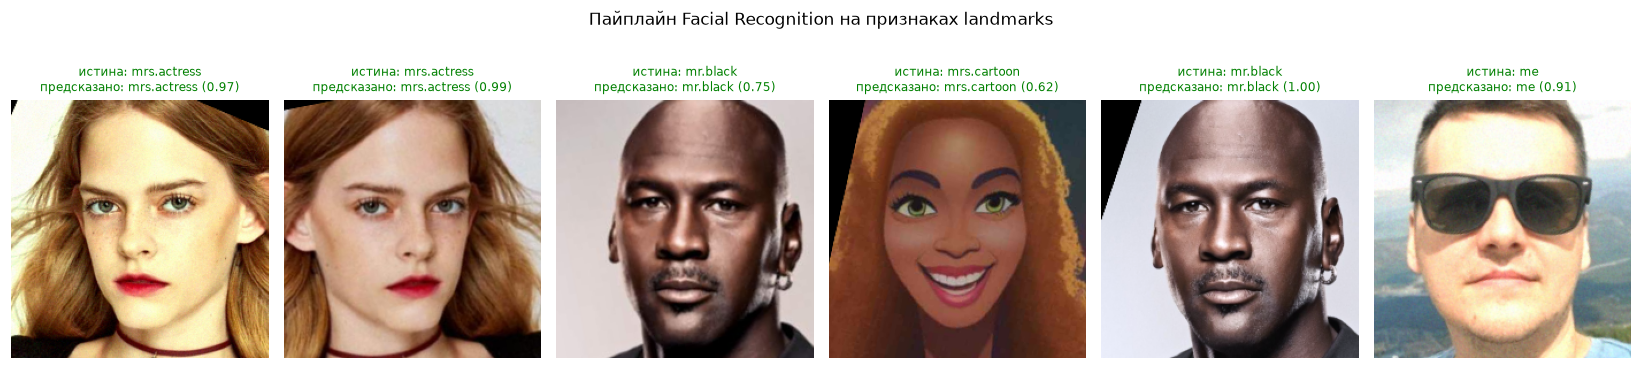

In [26]:
# Демонстрация на шести случайных test-кадрах (их модель не видела)
rng_demo = np.random.default_rng(SEED)
test_pool = [r for r in records if r["split"] == "test"]
demo = [test_pool[i] for i in rng_demo.choice(len(test_pool), size=6, replace=False)]

fig, axes = plt.subplots(1, len(demo), figsize=(2.5 * len(demo), 3.4))
for ax, r in zip(axes, demo):
    out = recognizer(r["image"])
    ax.axis("off")
    if not out["ok"]:
        ax.imshow(np.zeros((ALIGN_SIZE, ALIGN_SIZE, 3), np.uint8))
        ax.set_title(f"{r['person']}\n{out['reason']}", fontsize=8, color="red")
        continue
    ok = out["name"] == r["person"]
    ax.imshow(bgr2rgb(out["aligned"]))
    ax.set_title(f"истина: {r['person']}\nпредсказано: {out['name']} ({out['confidence']:.2f})",
                 fontsize=8, color="green" if ok else "red")
fig.suptitle("Пайплайн Facial Recognition на признаках landmarks", y=1.04)
plt.tight_layout();  plt.show()

In [27]:
# Сохраняем артефакты, чтобы результаты можно было перечитать без пересчёта
df_res.to_csv(OUT_DIR / "results_all.csv", index=False)
best.to_csv(OUT_DIR / "results_best.csv", index=False)
df_det.to_csv(OUT_DIR / "detector_stats.csv", index=False)
df_quality.to_csv(OUT_DIR / "feature_quality.csv", index=False)
df_summary.to_csv(OUT_DIR / "summary.csv")
print("сохранено в", OUT_DIR.relative_to(ROOT))
for p in sorted(OUT_DIR.glob("*.csv")):
    print("  ", p.name)

сохранено в output
   detector_stats.csv
   feature_quality.csv
   results_all.csv
   results_best.csv
   summary.csv


---

## 9. Выводы

### Что получилось

| | |
|---|---|
| точек на голове | 5 |
| размер дескриптора | 30 чисел, из них 9 константных |
| детекция сработала | на 304 кадрах из 305 |
| время на кадр | ≈ 10–15 мс на RTX 3090 |
| **landmarks → accuracy** | **0.96** (LogReg) |
| hog → accuracy | 1.00 |
| landmarks+hog → accuracy | 1.00 |

Пайплайн собран и работает.

### Информации в дескрипторе меньше, чем кажется

Среди 30 признаков, фактически работают только 6: координаты носа и ушей.

Поэтому 5 непохожих людей удалось классифицировать, большее количество под вопросом.

### Landmarks работает хуже, чем HOG

HOG по тому же самому выровненному кадру даёт 1.00 против 0.96 у landmarks. Кадр
один и тот же, разница только в том, что мы из него берём. Значит, личность
в основном в текстуре лица, а пять точек позы описывают лишь грубые пропорции
головы.

Отсюда вывод о ролях: pose landmarks хороши, чтобы найти лицо и выровнять его,
а опознавать должен другой признак — HOG, а лучше эмбеддинг вроде ArcFace.
Строка `landmarks+hog` = 1.00 ровно это и показывает.
